# Đồ Án: Phân tích và Ước lượng Độ mặn ĐBSCL (Spatiotemporal Regression)

Dự án này sử dụng Học máy (Machine Learning) để mô hình hóa và ước lượng độ mặn tại Đồng bằng sông Cửu Long dựa trên các yếu tố: Tọa độ Không gian, Thời gian (Mùa vụ) và Mực nước Châu Đốc.

### 1. Thu thập dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Tắt warning để báo cáo sạch đẹp

# 1. Đọc dữ liệu độ mặn
df_sal = pd.read_csv('../data/raw/CSDL_DSS1_20240109_1.csv', low_memory=False)
df_sal = df_sal.iloc[1:].copy() # Bỏ dòng đơn vị
df_sal['Date'] = pd.to_datetime(df_sal['Date'], format='%d/%m/%Y', errors='coerce')
df_sal['Salinity'] = pd.to_numeric(df_sal['Salinity'], errors='coerce')
df_sal['longitude'] = pd.to_numeric(df_sal['longitude'], errors='coerce')
df_sal['latitude'] = pd.to_numeric(df_sal['latitude'], errors='coerce')

# 2. Đọc dữ liệu mực nước Châu Đốc
df_wl = pd.read_csv('../data/raw/WaterLevel/ChauDoc_WaterLevel_2018_2026_15min.csv')
df_wl['ObservationDate'] = pd.to_datetime(df_wl['ObservationDate'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df_wl_daily = df_wl.groupby(df_wl['ObservationDate'].dt.date).agg(WaterLevel_Mean=('WaterLevel', 'mean')).reset_index()
df_wl_daily['ObservationDate'] = pd.to_datetime(df_wl_daily['ObservationDate'])

print('Salinity shape:', df_sal.shape)
print('Water Level daily shape:', df_wl_daily.shape)

Salinity shape: (2696, 33)
Water Level daily shape: (2059, 2)


### 2. Làm sạch dữ liệu

In [2]:
# Loại bỏ các dòng thiếu thông tin quan trọng
df_sal = df_sal.dropna(subset=['Date', 'Salinity', 'longitude', 'latitude']).sort_values('Date')
df_wl_daily = df_wl_daily.sort_values('ObservationDate')

# Ghép dữ liệu Mặn và Mực nước (lấy mực nước trong quá khứ gần nhất, tối đa 3 ngày)
df_clean = pd.merge_asof(df_sal, df_wl_daily, left_on='Date', right_on='ObservationDate', direction='backward', tolerance=pd.Timedelta('3 days'))
df_clean = df_clean.dropna(subset=['WaterLevel_Mean'])

print('Dữ liệu sau khi làm sạch và ghép:', df_clean.shape)
display(df_clean.head())

Dữ liệu sau khi làm sạch và ghép: (1020, 35)


,Matram,Kyhieu,longitude,latitude,Z.Elev,Date,pH,Aldrin,BHC,Dieldrin,...,N_NO3,N_NO2,P_PO4,Coliform,Ecoli,Salinity,TSS,CL,ObservationDate,WaterLevel_Mean
430,QLPH082019,QL8,105.46,9.44,0.44,2019-01-01,7.20,0.08,0.069,0.026,...,0.69,0.94,6.4,6400,0,0.8,4.95,82.69,2019-01-01,1.025281
431,QLPH032019,QL3,105.45,9.24,0.46,2019-01-01,7.14,0.078,0.067,0.025,...,0.42,0.95,5.9,5400,0,6.2,5.2,898.76,2019-01-01,1.025281
432,QLPH112019,QL11,105.46,9.55,0.41,2019-01-01,7.19,0.078,0.068,0.024,...,0.65,0.92,6.1,2800,0,0.3,5.47,3.15,2019-01-01,1.025281
433,QLPH062019,QL6,105.17,9.19,0.38,2019-01-01,6.49,0.045,0.035,0.012,...,0.71,0.149,6.4,9500,0,15.0,5.46,1691.27,2019-01-01,1.025281
434,QLPH022019,QL2,105.59,9.28,0.6,2019-01-01,6.24,0.051,0.041,0.01,...,0.16,0.33,5.2,3500,0,0.9,3.95,92.18,2019-01-01,1.025281


### 3. Khai phá và phân tích dữ liệu (EDA)

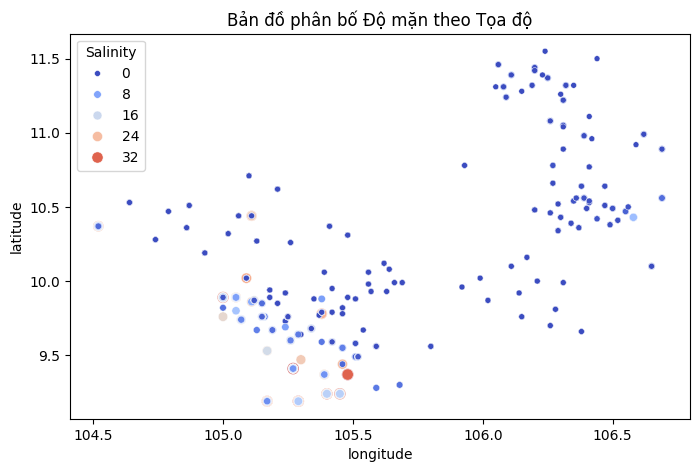

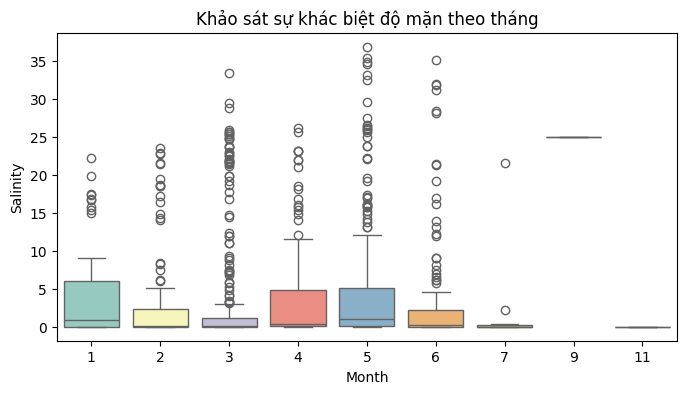

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='Salinity', size='Salinity', palette='coolwarm')
plt.title('Bản đồ phân bố Độ mặn theo Tọa độ')
plt.show()

df_clean['Month'] = df_clean['Date'].dt.month
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x='Month', y='Salinity', hue='Month', palette='Set3', legend=False)
plt.title('Khảo sát sự khác biệt độ mặn theo tháng')
plt.show()

### 4. Lập mô hình học máy
Sử dụng các thuật toán Machine Learning (Random Forest, XGBoost) để xây dựng bài toán Hồi quy Không-Thời gian (Spatiotemporal Regression).

In [4]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Khởi tạo mô hình cơ bản
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

### 5. Xây dựng Feature và Chia tập dữ liệu
Sử dụng thông tin vị trí (Lat, Lon), tháng và biến proxy (Mực nước Châu Đốc) để ước lượng độ mặn. Huấn luyện trên dữ liệu trước 2022 và kiểm thử trên dữ liệu năm 2022.

In [5]:
features = ['longitude', 'latitude', 'Month', 'WaterLevel_Mean']
target = 'Salinity'

df_clean['Year'] = df_clean['Date'].dt.year
train_df = df_clean[df_clean['Year'] < 2022]
test_df = df_clean[df_clean['Year'] == 2022]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f'Kích thước tập Train: {len(X_train)}')
print(f'Kích thước tập Test: {len(X_test)}')

Kích thước tập Train: 681
Kích thước tập Test: 339


### 6. Đánh giá và So sánh mô hình (Sử dụng Log Transformation)
Dùng `log1p` để giảm ảnh hưởng của phân phối target lệch và đánh giá lại kết quả trên thang độ mặn gốc bằng hàm `np.expm1`.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_log(model, name):
    # Huấn luyện trên không gian Logarit
    model.fit(X_train, np.log1p(y_train))
    # Dự báo và bung log
    y_pred_log = model.predict(X_test)
    y_pred = np.clip(np.expm1(y_pred_log), 0, None)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    return {'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae}, y_pred

# 1. Baseline: Trung bình của trạm lịch sử
station_means = train_df.groupby('Kyhieu')['Salinity'].mean().to_dict()
pred_baseline = test_df['Kyhieu'].map(station_means).fillna(train_df['Salinity'].mean())
res_baseline = {'Model': 'Station Mean (Baseline)', 'R2 Score': r2_score(y_test, pred_baseline), 
                'RMSE': np.sqrt(mean_squared_error(y_test, pred_baseline)), 'MAE': mean_absolute_error(y_test, pred_baseline)}

# 2. Đánh giá Model
res_rf, pred_rf = evaluate_log(model_rf, 'Random Forest (Log1p)')
res_xgb, pred_xgb = evaluate_log(model_xgb, 'XGBoost (Log1p)')

results_df = pd.DataFrame([res_baseline, res_rf, res_xgb])
display(results_df)

,Model,R2 Score,RMSE,MAE
0,Station Mean (Baseline),0.036197,6.677514,4.204458
1,Random Forest (Log1p),0.372239,5.389119,2.989607
2,XGBoost (Log1p),0.211530,6.039673,3.145155


### 7. Truyền đạt kết quả và Triển khai thực tiễn

**7.1. Phân phối sai số (Residual Analysis)**
Kiểm tra xem các sai số (Thực tế - Ước lượng) có tập trung quanh mức 0 hay không.

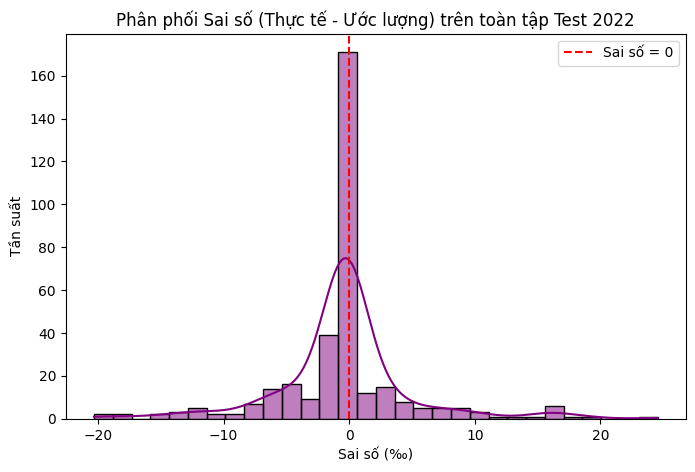

In [7]:
residuals = y_test - pred_rf
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Phân phối Sai số (Thực tế - Ước lượng) trên toàn tập Test 2022')
plt.xlabel('Sai số (‰)')
plt.ylabel('Tần suất')
plt.axvline(x=0, color='red', linestyle='--', label='Sai số = 0')
plt.legend()
plt.show()

**7.2. Đối chiếu chi tiết tại Trạm QL1 (Năm 2022)**
Trích xuất trạm QL1 để so sánh thực tế và ước lượng. Biểu đồ dùng dạng phân tán (Scatter).

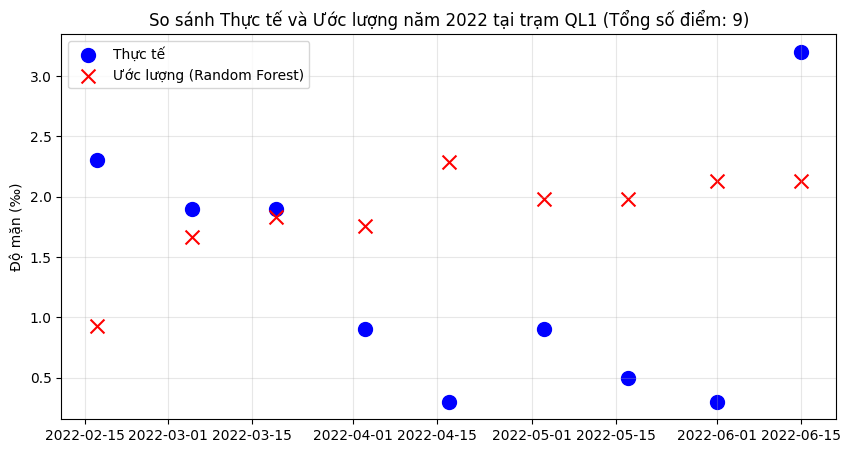

In [8]:
tram_test = 'QL1'
df_tram = test_df[test_df['Kyhieu'] == tram_test].copy()
if not df_tram.empty:
    df_tram['UocLuong'] = np.clip(np.expm1(model_rf.predict(df_tram[features])), 0, None)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(df_tram['Date'], df_tram['Salinity'], c='blue', s=100, label='Thực tế')
    plt.scatter(df_tram['Date'], df_tram['UocLuong'], c='red', marker='x', s=100, label='Ước lượng (Random Forest)')
    plt.title(f'So sánh Thực tế và Ước lượng năm 2022 tại trạm {tram_test} (Tổng số điểm: {len(df_tram)})')
    plt.ylabel('Độ mặn (‰)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()